In [14]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1/train_image_paths.csv')
print(df.head())

  MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png
0  MURA-v1.1/train/XR_SHOULDER/patient00001/study...                 
1  MURA-v1.1/train/XR_SHOULDER/patient00001/study...                 
2  MURA-v1.1/train/XR_SHOULDER/patient00002/study...                 
3  MURA-v1.1/train/XR_SHOULDER/patient00002/study...                 
4  MURA-v1.1/train/XR_SHOULDER/patient00002/study...                 


In [15]:
df_train = pd.read_csv('/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1/train_image_paths.csv')
print(df_train.columns)

Index(['MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png'], dtype='object')


In [16]:
import pandas as pd
import os

BASE_PATH = '/kaggle/input/datasets/cjinny/mura-v11'

df_train = pd.read_csv(f'{BASE_PATH}/MURA-v1.1/train_image_paths.csv', header=None)
df_train.columns = ['image_path']
df_train['path'] = df_train['image_path'].apply(lambda x: os.path.join(BASE_PATH, x))
df_train['label'] = df_train['image_path'].apply(lambda x: 1 if 'positive' in x else 0)
df_train['body_part'] = df_train['image_path'].apply(lambda x: x.split('/')[2])


df_test = pd.read_csv(f'{BASE_PATH}/MURA-v1.1/valid_image_paths.csv', header=None)
df_test.columns = ['image_path']
df_test['path'] = df_test['image_path'].apply(lambda x: os.path.join(BASE_PATH, x))
df_test['label'] = df_test['image_path'].apply(lambda x: 1 if 'positive' in x else 0)
df_test['body_part'] = df_test['image_path'].apply(lambda x: x.split('/')[2])
print(df_test.head())
print(df_train.head())

                                          image_path  \
0  MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...   
1  MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...   
2  MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...   
3  MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...   
4  MURA-v1.1/valid/XR_WRIST/patient11186/study1_p...   

                                                path  label body_part  
0  /kaggle/input/datasets/cjinny/mura-v11/MURA-v1...      1  XR_WRIST  
1  /kaggle/input/datasets/cjinny/mura-v11/MURA-v1...      1  XR_WRIST  
2  /kaggle/input/datasets/cjinny/mura-v11/MURA-v1...      1  XR_WRIST  
3  /kaggle/input/datasets/cjinny/mura-v11/MURA-v1...      1  XR_WRIST  
4  /kaggle/input/datasets/cjinny/mura-v11/MURA-v1...      1  XR_WRIST  
                                          image_path  \
0  MURA-v1.1/train/XR_SHOULDER/patient00001/study...   
1  MURA-v1.1/train/XR_SHOULDER/patient00001/study...   
2  MURA-v1.1/train/XR_SHOULDER/patient00001/study...   
3  MURA

In [17]:
from sklearn.model_selection import train_test_split

# Create a stratification key combining body part + label
df_train['stratify_group'] = df_train['body_part'] + "_" + df_train['label'].astype(str)

# Stratified 80/20 split
df_train_final, df_val_final = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train['stratify_group']
)


In [18]:
# Distribution and Sanity Check

print("Training set:")
print(df_train_final['body_part'].value_counts(normalize=True))

print("\nValidation set:")
print(df_val_final['body_part'].value_counts(normalize=True))

Training set:
body_part
XR_WRIST       0.264960
XR_SHOULDER    0.227637
XR_HAND        0.150581
XR_FINGER      0.138695
XR_ELBOW       0.133974
XR_FOREARM     0.049582
XR_HUMERUS     0.034572
Name: proportion, dtype: float64

Validation set:
body_part
XR_WRIST       0.264874
XR_SHOULDER    0.227656
XR_HAND        0.150638
XR_FINGER      0.138821
XR_ELBOW       0.133931
XR_FOREARM     0.049579
XR_HUMERUS     0.034501
Name: proportion, dtype: float64


In [19]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import numpy as np

class MuraDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["path"]
        label = row["label"]

        image = Image.open(image_path).convert("L")
        if self.transform:
            image = self.transform(image)

        return image, label 
print("Dataset defined!")

Dataset defined!


In [20]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize before augmenting
    transforms.RandomHorizontalFlip(p=0.5),   # Minor flip — common in medical images
    transforms.RandomRotation(degrees=10),    # Small angle preserves structure
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Slight lighting changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # For grayscale

])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # For grayscale

])

In [21]:
from torch.utils.data import DataLoader

# Train
train_dataset = MuraDataset(df_train_final, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

# Validation
val_dataset = MuraDataset(df_val_final, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


# Test
test_dataset = MuraDataset(df_test, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [22]:
import torch
import torch.nn as nn
from torchvision.models import densenet169

# CBAM Module
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x).view(x.size(0), -1))
        max = self.fc(self.max_pool(x).view(x.size(0), -1))
        out = self.sigmoid(avg + max)
        return x * out.view(x.size(0), x.size(1), 1, 1)

class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg, max], dim=1)
        out = self.sigmoid(self.conv(out))
        return x * out

class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

# DenseNet169 + CBAM 
class DenseNet169Fracture(nn.Module):
    def __init__(self, pretrained=True):
        super(DenseNet169Fracture, self).__init__()

        weights = 'IMAGENET1K_V1' if pretrained else None
        base = densenet169(weights=weights)

        # Grayscale input
        original_conv = base.features.conv0
        base.features.conv0 = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False
        )

        self.features = base.features
        self.cbam = CBAM(1664)  # DenseNet169 last channel = 1664
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.feature_dim = base.classifier.in_features

        # Fracture head
        self.fracture_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)  # CBAM apply
        x = self.pool(x).view(x.size(0), -1)
        return self.fracture_head(x)

print("DenseNet169 + CBAM defined!")

DenseNet169 + CBAM defined!


In [23]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
import torch
import torch.nn as nn

fracture_loss_fn = nn.CrossEntropyLoss()

# Model 
model = DenseNet169Fracture(pretrained=True).to(device)

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print("Model ready!")

Model ready!


In [25]:
def train_one_epoch(model, loader, optimizer, fracture_loss_fn):
    model.train()
    total_loss, correct_frac = 0, 0

    for images, labels in loader:  
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        out_fracture = model(images)  

        loss = fracture_loss_fn(out_fracture, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct_frac += (out_fracture.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / len(loader), correct_frac / n


def validate(model, loader, fracture_loss_fn):
    model.eval()
    total_loss, correct_frac = 0, 0

    with torch.no_grad():
        for images, labels in loader: 
            images = images.to(device)
            labels = labels.to(device)

            out_fracture = model(images)  

            loss = fracture_loss_fn(out_fracture, labels)

            total_loss += loss.item()
            correct_frac += (out_fracture.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / len(loader), correct_frac / n

print("Functions defined!")

Functions defined!


In [26]:
import torch
from sklearn.metrics import roc_curve, auc

best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 5
epochs = 30

# CURVE STORAGE
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):

    train_loss, train_fracture_acc = train_one_epoch(
        model, train_loader, optimizer, fracture_loss_fn  
    )

    val_loss, val_fracture_acc = validate(
        model, val_loader, fracture_loss_fn 
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_fracture_acc)
    val_accs.append(val_fracture_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Frac Acc: {train_fracture_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Frac Acc: {val_fracture_acc:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), "/kaggle/working/densenet_mura.pt")
        print(f"Best model saved! Val Loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"Early stop patience: {early_stop_counter}/5")
        if early_stop_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

# ROC CURVE
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader: 
        images = images.to(device)
        labels = labels.to(device)
        out_fracture = model(images)  
        probs = torch.softmax(out_fracture, dim=1)[:, 1]
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f} ")

Epoch 1/30 | Train Loss: 0.5703, Frac Acc: 0.7095 | Val Loss: 0.5092, Frac Acc: 0.7637
Best model saved! Val Loss: 0.5092
Epoch 2/30 | Train Loss: 0.5043, Frac Acc: 0.7639 | Val Loss: 0.4895, Frac Acc: 0.7694
Best model saved! Val Loss: 0.4895
Epoch 3/30 | Train Loss: 0.4808, Frac Acc: 0.7815 | Val Loss: 0.4794, Frac Acc: 0.7825
Best model saved! Val Loss: 0.4794
Epoch 4/30 | Train Loss: 0.4685, Frac Acc: 0.7902 | Val Loss: 0.4721, Frac Acc: 0.7916
Best model saved! Val Loss: 0.4721
Epoch 5/30 | Train Loss: 0.4590, Frac Acc: 0.7973 | Val Loss: 0.4606, Frac Acc: 0.7919
Best model saved! Val Loss: 0.4606
Epoch 6/30 | Train Loss: 0.4558, Frac Acc: 0.7970 | Val Loss: 0.4521, Frac Acc: 0.7957
Best model saved! Val Loss: 0.4521
Epoch 7/30 | Train Loss: 0.4478, Frac Acc: 0.8048 | Val Loss: 0.4434, Frac Acc: 0.8010
Best model saved! Val Loss: 0.4434
Epoch 8/30 | Train Loss: 0.4418, Frac Acc: 0.8066 | Val Loss: 0.4369, Frac Acc: 0.8066
Best model saved! Val Loss: 0.4369
Epoch 9/30 | Train Loss:

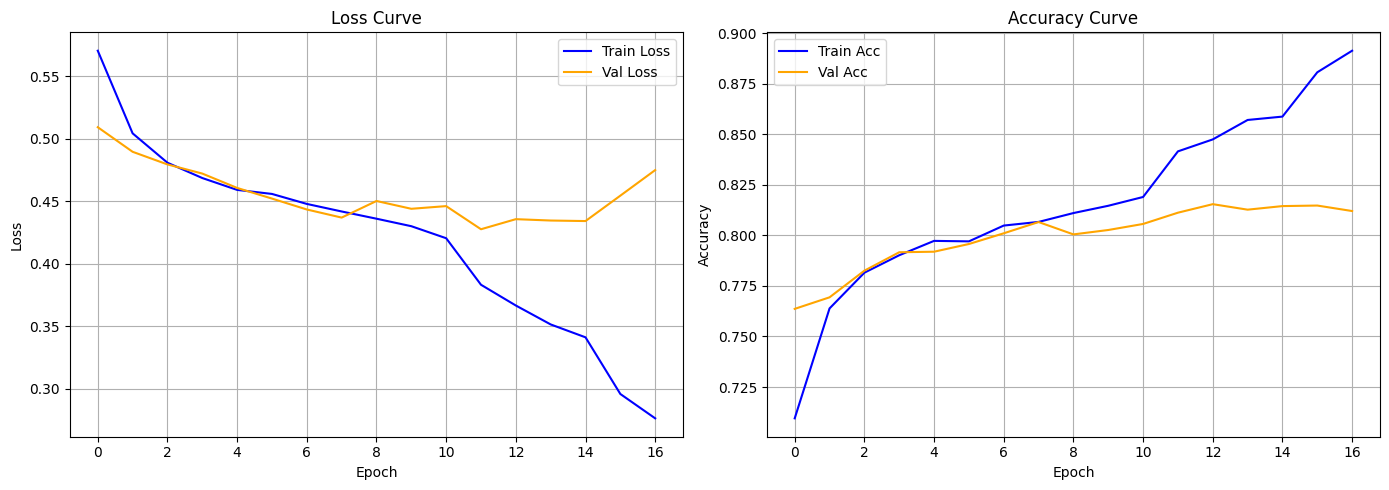

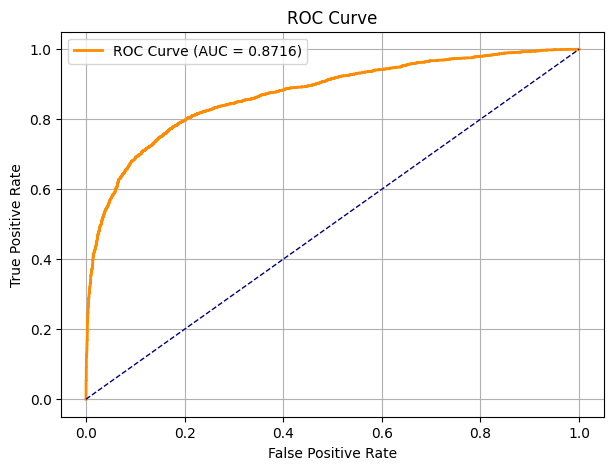

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='orange')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy Curve
axes[1].plot(train_accs, label='Train Acc', color='blue')
axes[1].plot(val_accs, label='Val Acc', color='orange')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/densenet_curves.png', dpi=150) 
plt.show()

# ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.savefig('/kaggle/working/densenet_roc.png', dpi=150)   
plt.show()

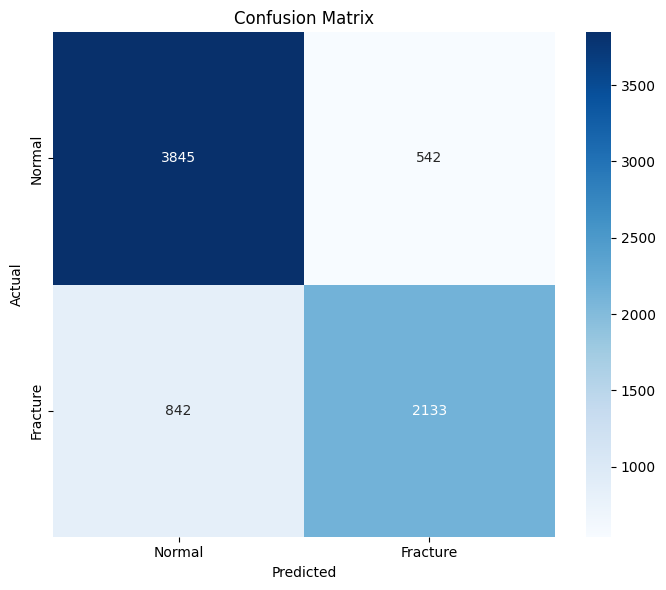

              precision    recall  f1-score   support

      Normal       0.82      0.88      0.85      4387
    Fracture       0.80      0.72      0.76      2975

    accuracy                           0.81      7362
   macro avg       0.81      0.80      0.80      7362
weighted avg       0.81      0.81      0.81      7362



In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
# Predictions 
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        preds = torch.argmax(out, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Normal', 'Fracture']
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/kaggle/working/densenet_confusion_matrix.png', dpi=150)
plt.show()
# Classification Report
print(classification_report(all_labels, all_preds, target_names=class_names)) 

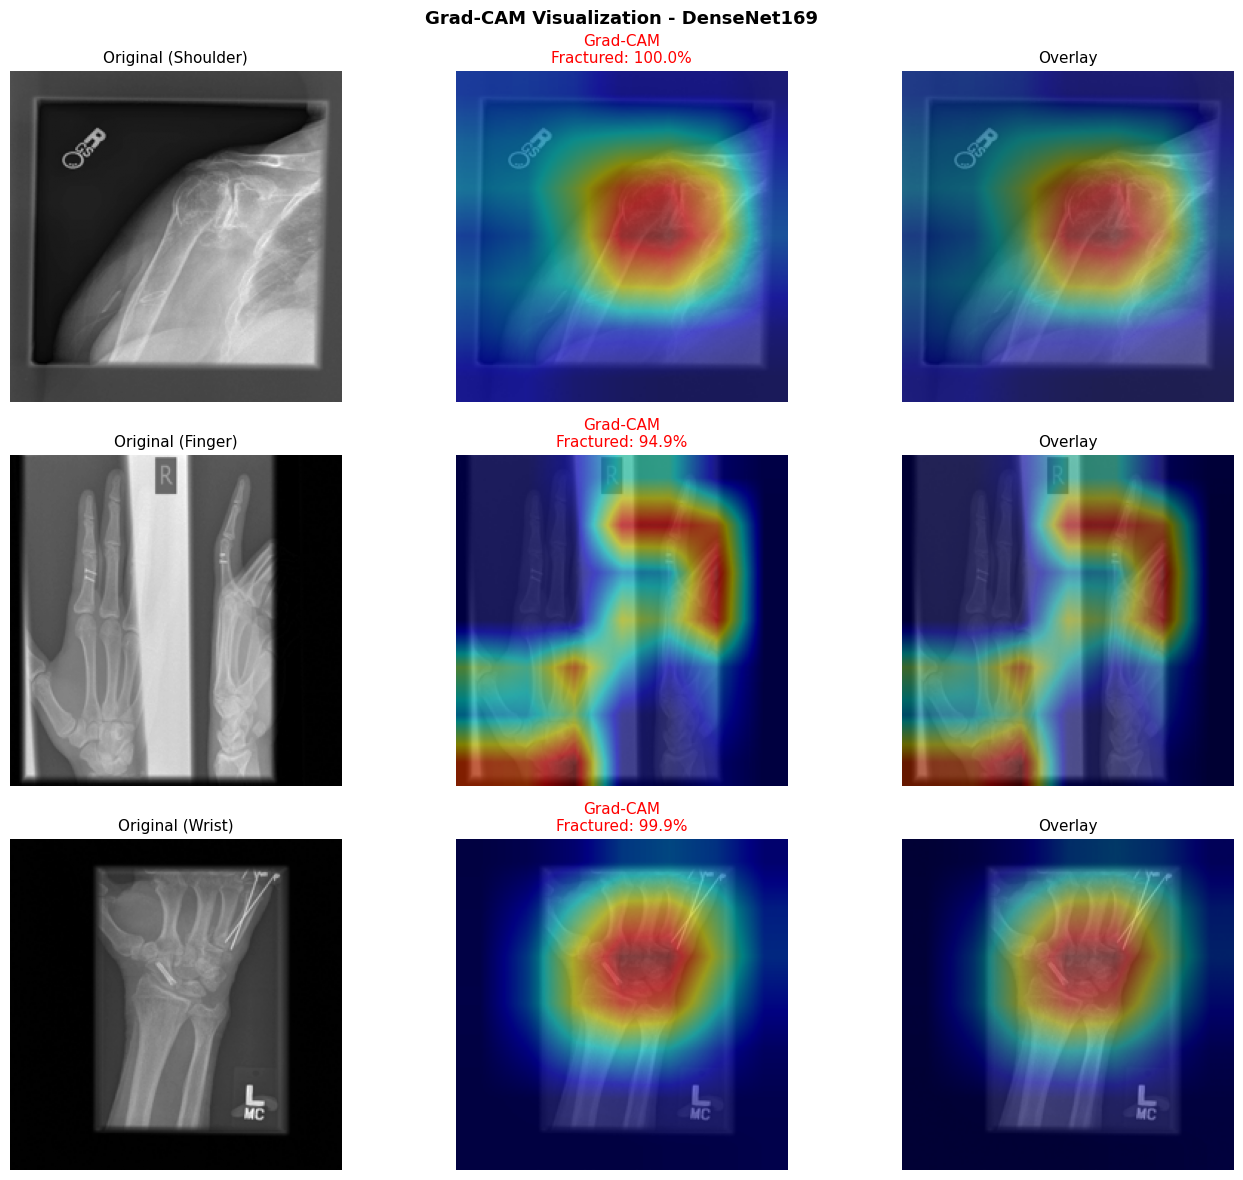

Saved!


In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torchvision.transforms as transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=1):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Target layer 
target_layer = model.features.denseblock4
gradcam = GradCAM(model, target_layer)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


selected_paths = [
   '/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1/valid/XR_SHOULDER/patient11300/study2_positive/image3.png',
    '/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1/valid/XR_FINGER/patient11916/study1_positive/image2.png',
    '/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1/valid/XR_WRIST/patient11243/study1_positive/image3.png'
]
confidences = [100.0, 94.9, 99.9]
body_parts = ['Shoulder', 'Finger', 'Wrist']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, (sample_path, confidence, body_part) in enumerate(zip(selected_paths, confidences, body_parts)):
    image = Image.open(sample_path).convert('L')
    input_tensor = transform(image).unsqueeze(0).to(device)
    cam = gradcam.generate(input_tensor, class_idx=1)
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    orig = np.array(image.resize((224, 224)))
    orig_rgb = np.stack([orig] * 3, axis=-1)
    overlay = (0.6 * orig_rgb / 255 + 0.4 * heatmap / 255)
    overlay = np.clip(overlay, 0, 1)
    overlay = (overlay * 255).astype(np.uint8)
    gradcam_on_xray = (0.5 * orig_rgb + 0.5 * heatmap).astype(np.uint8)
    axes[i][0].imshow(orig, cmap='gray')
    axes[i][0].set_title(f'Original ({body_part})', fontsize=11)
    axes[i][0].axis('off')
    axes[i][1].imshow(gradcam_on_xray)
    axes[i][1].set_title(f'Grad-CAM\nFractured: {confidence:.1f}%', color='red', fontsize=11)
    axes[i][1].axis('off')
    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Overlay', fontsize=11)
    axes[i][2].axis('off')

plt.suptitle('Grad-CAM Visualization - DenseNet169', fontsize=13, fontweight='bold')  # ✅
plt.tight_layout()
plt.savefig('/kaggle/working/densenet_gradcam_final.png', dpi=300, bbox_inches='tight')  # ✅
plt.show()
print("Saved!")

2026-06-01 11:53:18.832877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780314799.029972      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780314799.082734      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780314799.522335      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780314799.522378      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780314799.522381      58 computation_placer.cc:177] computation placer alr

Features shape: (3197, 1664)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


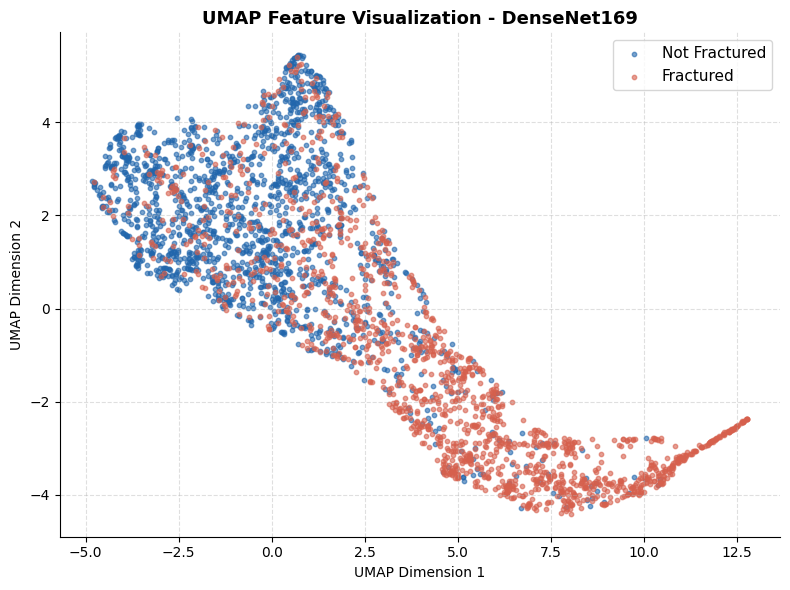

UMAP saved!


In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
from PIL import Image
import torchvision.transforms as transforms

model.eval()
features = []
labels_list = []

transform_umap = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

feature_hook = []

def hook_fn(module, input, output):
    feature_hook.append(output.detach().cpu())

hook = model.pool.register_forward_hook(hook_fn)  # ✅ DenseNet এও same

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _ = model(images)
        labels_list.extend(labels.numpy())

hook.remove()

all_features = torch.cat(feature_hook, dim=0).squeeze().numpy()
all_labels = np.array(labels_list)
print(f"Features shape: {all_features.shape}")

reducer = UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(all_features)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: '#2166AC', 1: '#D6604D'}
label_names = {0: 'Not Fractured', 1: 'Fractured'}

for label in [0, 1]:
    mask = all_labels == label
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=colors[label],
        label=label_names[label],
        alpha=0.6,
        s=10
    )

ax.set_title('UMAP Feature Visualization - DenseNet169', fontweight='bold', fontsize=13)  # ✅
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/densenet_umap.png', dpi=300, bbox_inches='tight')  # ✅
plt.show()
print("UMAP saved!")

In [42]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [43]:
import os
print(os.listdir('/kaggle/input/datasets'))

['bmadushanirodrigo', 'cjinny']


In [44]:
import os
from glob import glob

BASE2 = '/kaggle/input/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'

fractured_paths = glob(os.path.join(BASE2, 'test/fractured', '*'))
not_fractured_paths = glob(os.path.join(BASE2, 'test/not fractured', '*'))

print(f"Fractured images: {len(fractured_paths)}")
print(f"Not Fractured images: {len(not_fractured_paths)}")

Fractured images: 238
Not Fractured images: 268


In [46]:
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class CustomXrayDataset(Dataset):
    def __init__(self, image_paths, label, transform=None):
        self.image_paths = image_paths
        self.label = label
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, self.label 

print("CustomXrayDataset defined!")

CustomXrayDataset defined!


In [47]:
from torch.utils.data import DataLoader

fractured_ds = CustomXrayDataset(fractured_paths, label=1, transform=test_transform)
notfractured_ds = CustomXrayDataset(not_fractured_paths, label=0, transform=test_transform)

from torch.utils.data import ConcatDataset

combined_ds = ConcatDataset([fractured_ds, notfractured_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False)

In [48]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in combined_loader:  
        images = images.to(device)
        labels = labels.to(device)

        out_fracture = model(images) 
        preds = out_fracture.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions done!")

Predictions done!


In [50]:
from sklearn.metrics import classification_report, confusion_matrix

print("Custom X-Ray Evaluation:")
print(classification_report(all_labels, all_preds, target_names=["Not Fractured", "Fractured"]))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Custom X-Ray Evaluation:
               precision    recall  f1-score   support

Not Fractured       0.66      0.85      0.75       268
    Fractured       0.76      0.51      0.61       238

     accuracy                           0.69       506
    macro avg       0.71      0.68      0.68       506
 weighted avg       0.71      0.69      0.68       506

Confusion Matrix:
[[229  39]
 [117 121]]
